In [1]:
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub  # Kaggle dataset download

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
torch.manual_seed(42) # 관습적 42
np.random.seed(42)

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")


Using device: cuda
PyTorch version: 2.8.0+cu126


In [2]:
# Install dependencies needed for this notebook
%pip install pandas numpy matplotlib scikit-learn kagglehub

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Load Energy Consumption Dataset

import os
import kagglehub
import pandas as pd

# 1) Download dataset using KaggleHub
path = kagglehub.dataset_download(
    "govindaramsriram/energy-consumption-dataset-linear-regression"
)
train_path = os.path.join(path, "train_energy_data.csv")

# 2) Load CSV(Comma-Separated Values)
df = pd.read_csv(train_path)

print("Dataset Information:")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1}")  # target(energy consumption) -> -1 
print("\nColumns:", df.columns.tolist())

# 3) Set target
target_col = "Energy Consumption"
y = df[target_col].values

# 4) Select numeric features 
numeric_cols = ["Square Footage", "Number of Occupants", "Appliances Used", "Average Temperature"]
X = df[numeric_cols]

print("\nUsing numeric features only:", numeric_cols)

# 5) Print basic statistics of the target
print("\nTarget (Energy Consumption) statistics:")
print(f"  Min: {y.min():.2f}")
print(f"  Max: {y.max():.2f}")
print(f"  Mean: {y.mean():.2f}")


Dataset Information:
Number of samples: 1000
Number of features: 6

Columns: ['Building Type', 'Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature', 'Day of Week', 'Energy Consumption']

Using numeric features only: ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']

Target (Energy Consumption) statistics:
  Min: 1683.95
  Max: 6530.60
  Mean: 4166.25


In [4]:
# Split dataset into train/test + Normalize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1) Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 #관습적 42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# 2) Normalize numeric features 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n✓ Data normalized (mean=0, std=1)")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")


Training set size: 800 samples
Test set size: 200 samples

✓ Data normalized (mean=0, std=1)
X_train_scaled shape: (800, 4)
X_test_scaled shape:  (200, 4)


In [5]:
# Convert to PyTorch tensors & DataLoaders

# Numpy → PyTorch tensors
# X_*_scaled : (N, 4)  /  y_* : (N,)
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)  # (N,) -> (N, 1), 1D ->2D
X_test_tensor  = torch.FloatTensor(X_test_scaled)
y_test_tensor  = torch.FloatTensor(y_test).reshape(-1, 1)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_test_tensor shape :", X_test_tensor.shape)
print("y_test_tensor shape :", y_test_tensor.shape)

# Using TensorDataset to combine features and targets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader: Provides mini-batches of data
batch_size = 64  # Adjust based on your computer's capability (commonly 2^n: 16, 32, 64, etc.)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nBatch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")


X_train_tensor shape: torch.Size([800, 4])
y_train_tensor shape: torch.Size([800, 1])
X_test_tensor shape : torch.Size([200, 4])
y_test_tensor shape : torch.Size([200, 1])

Batch size: 64
Number of training batches: 13
Number of test batches: 4


In [6]:
# =========================================
# Define Regression Model (Energy Dataset)
# =========================================

class RegressionModel(nn.Module):
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32):
        super(RegressionModel, self).__init__()
        
        # 3-layer MLP (Fully Connected Network)
        self.fc1 = nn.Linear(input_size, hidden_size1)  # Input → Hidden1
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(hidden_size1, hidden_size2)  # Hidden1 → Hidden2
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(hidden_size2, 1)  # Hidden2 → Output (Energy Consumption)
        
    def forward(self, x):
        # Forward propagation through the layers
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize model
# 우리 데이터: 숫자형 피처 4개 → input_size = 4
input_size = X_train_scaled.shape[1]  # Number of features (4)

model = RegressionModel(input_size).to(device)

print(model)
print(f"\nModel moved to: {device}")


RegressionModel(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

Model moved to: cuda


In [7]:
# =========================================
# Loss Function & Optimizer 설정
# =========================================

# 회귀 문제 → MSELoss 사용
# Energy Consumption 값이 1000~7000 단위라 MSE는 꽤 큰 값이 나올 수 있음
criterion = nn.MSELoss()

# Optimizer: Adam
# 기본 lr=0.001은 대부분의 회귀용 MLP에서 안정적으로 잘 학습됨
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print("Loss function :", criterion)
print("Optimizer     : Adam")
print("Learning rate :", learning_rate)


Loss function : MSELoss()
Optimizer     : Adam
Learning rate : 0.001


In [8]:
# =========================================
# Training Loop (Energy Consumption Model)
# =========================================

# Epoch 수: 처음에는 50~100 정도로 돌려보고,
# 과제 테스트 용도로는 20으로 줄여서 빠르게 실험해도 됨.
num_epochs = 100  # 필요하면 20으로 줄여서 빠른 실험 가능

# 손실값 저장 (시각화 & 과적합 여부 확인용)
train_losses = []
test_losses = []

print("Starting training...")
print("-" * 60)

for epoch in range(num_epochs):
    # --------- Training Phase ---------
    model.train()
    train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        # GPU / CPU 로 데이터 이동
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # 1. Forward pass: 예측값 계산
        predictions = model(X_batch)
        
        # 2. 손실 계산 (MSE)
        loss = criterion(predictions, y_batch)
        
        # 3. Backward pass: 기울기(gradient) 계산
        optimizer.zero_grad()   # 기존 gradient 초기화
        loss.backward()         # 새로운 gradient 계산
        
        # 4. 가중치 업데이트
        optimizer.step()
        
        # 배치 손실 누적
        train_loss += loss.item()
    
    # Epoch별 평균 train loss
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --------- Evaluation Phase ---------
    model.eval()
    test_loss = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            test_loss += loss.item()
    
    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    # 진행상황 출력 (10 epoch마다)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Test Loss: {avg_test_loss:.4f}")

print("-" * 60)
print("Training complete!")


Starting training...
------------------------------------------------------------
Epoch [10/100] | Train Loss: 17911965.9231 | Test Loss: 18103192.7500
Epoch [20/100] | Train Loss: 16916796.0000 | Test Loss: 16985639.0000
Epoch [30/100] | Train Loss: 14118213.7692 | Test Loss: 14005251.2500
Epoch [40/100] | Train Loss: 9497533.1538 | Test Loss: 9366799.7500
Epoch [50/100] | Train Loss: 4852934.0192 | Test Loss: 4708870.2500
Epoch [60/100] | Train Loss: 1856155.4808 | Test Loss: 1802011.2188
Epoch [70/100] | Train Loss: 729385.8606 | Test Loss: 726035.2500
Epoch [80/100] | Train Loss: 473854.6394 | Test Loss: 469447.3281
Epoch [90/100] | Train Loss: 429422.0024 | Test Loss: 412963.0938
Epoch [100/100] | Train Loss: 406551.4880 | Test Loss: 393903.0547
------------------------------------------------------------
Training complete!


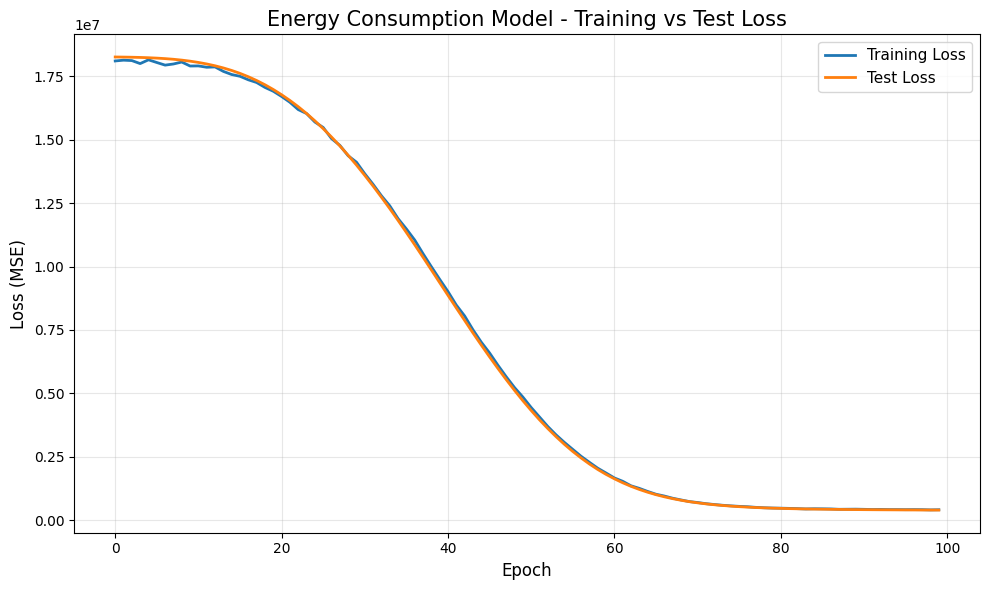

Final Training Loss: 406551.4880
Final Test Loss:    393903.0547


In [ ]:
# =========================================
# Visualization: Train/Test Loss Curve
# =========================================

plt.figure(figsize=(10, 6))

# Loss curves
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Energy Consumption Model - Training vs Test Loss', fontsize=15)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Test Loss:    {test_losses[-1]:.4f}")


In [ ]:
# Evaluation

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_pred = model(X_test_device).cpu().numpy()
    y_true = y_test_tensor.numpy()

# calulate metrics
mse  = mean_squared_error(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

print("Model Performance on Test Set:")
print("=" * 50)
print(f"Mean Squared Error (MSE):      {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"R² Score:                        {r2:.4f}")
print("=" * 50)

# Interpretation (units depend on dataset description: kWh, MJ, etc.)
print("\nInterpretation:")
print(f"On average, predictions are off by about {mae:.2f} units of energy consumption.")
print(f"The model explains approximately {r2*100:.2f}% of the variance in energy consumption.")


Model Performance on Test Set:
Mean Squared Error (MSE):      397443.9062
Root Mean Squared Error (RMSE): 630.4315
Mean Absolute Error (MAE):      518.5826
R² Score:                        0.5119

Interpretation:
On average, predictions are off by about 518.58 units of energy consumption.
The model explains approximately 51.19% of the variance in energy consumption.


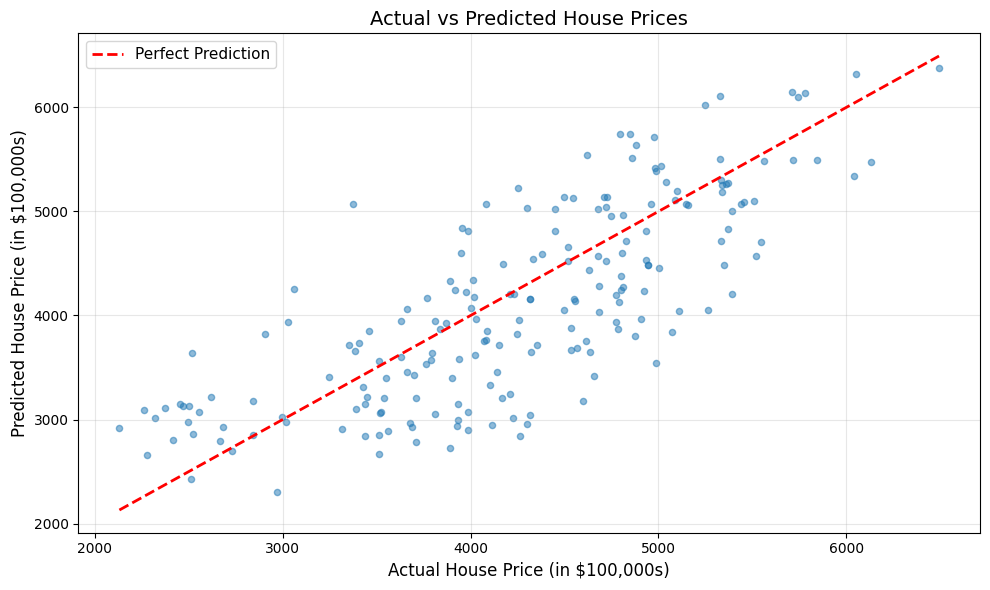


Sample Predictions (first 10 houses):
------------------------------------------------------------
      Actual |    Predicted |   Difference
------------------------------------------------------------
$454,958,976 | $416,144,736 | $38,814,240
$284,290,976 | $285,423,104 | $-1,132,128
$578,182,976 | $613,411,264 | $-35,228,288
$477,354,016 | $419,704,448 | $57,649,568
$379,104,000 | $356,847,424 | $22,256,576
$247,059,008 | $313,010,880 | $-65,951,872
$500,304,992 | $445,734,528 | $54,570,464
$331,412,000 | $291,168,448 | $40,243,552
$514,710,976 | $506,878,368 | $ 7,832,608
$429,892,000 | $502,889,792 | $-72,997,792


In [ ]:
# Create scatter plot of predictions vs actual values

plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.5, s=20)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual House Price (in $100,000s)', fontsize=12)
plt.ylabel('Predicted House Price (in $100,000s)', fontsize=12)
plt.title('Actual vs Predicted House Prices', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show some sample predictions
print("\nSample Predictions (first 10 houses):")
print("-" * 60)
print(f"{'Actual':>12} | {'Predicted':>12} | {'Difference':>12}")
print("-" * 60)
for i in range(min(10, len(y_true))):
    actual = y_true[i][0] * 100000
    predicted = y_pred[i][0] * 100000
    diff = actual - predicted
    print(f"${actual:>10,.0f} | ${predicted:>10,.0f} | ${diff:>10,.0f}")